In [19]:
from moon_position import moon_position
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from plotting import orbit_cartesian

# Positions of the Moon

In [8]:
# ── Validation against Meeus (1998) worked example, p.342 ────────────────────

# Meeus example: 1992 April 12, 0h TT
# Expected: lambda = 133.167°, beta = -3.229°, Delta = 368409 km
pos = moon_position(1992, 4, 12, 0, 0, 0)
print("Validation — Meeus (1998) p.342 worked example:")
print(f"  lambda = {pos['lambda_']:.3f}°  (expected 133.167°)")
print(f"  beta   = {pos['beta']:.3f}°  (expected -3.229°)")
print(f"  Delta  = {pos['Delta']:.0f} km  (expected 368409 km)")
print()
pos2 = moon_position(2026, 6, 29, 0, 58, 0)
print("Full Moon, 29 June 2026 00:58 BST (= 23:58 UTC 28 June):")
print(f"  lambda = {pos2['lambda_']:.3f}°")
print(f"  beta   = {pos2['beta']:.3f}°")
print(f"  Delta  = {pos2['Delta']:.0f} km")

Validation — Meeus (1998) p.342 worked example:
  lambda = 133.174°  (expected 133.167°)
  beta   = -3.230°  (expected -3.229°)
  Delta  = 368409 km  (expected 368409 km)

Full Moon, 29 June 2026 00:58 BST (= 23:58 UTC 28 June):
  lambda = 266.858°
  beta   = -4.582°
  Delta  = 406064 km


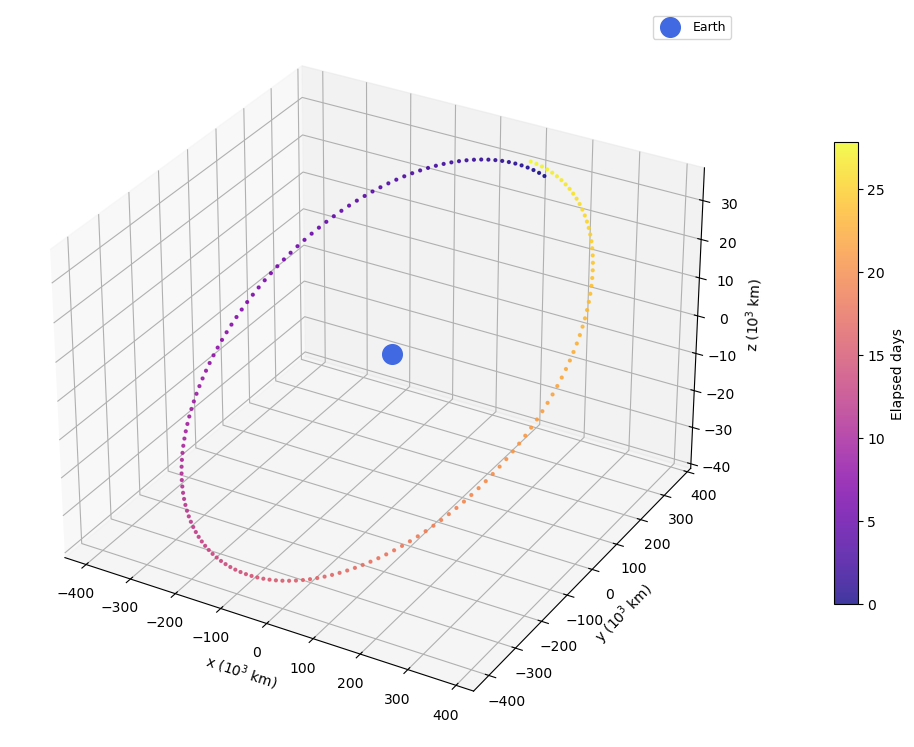

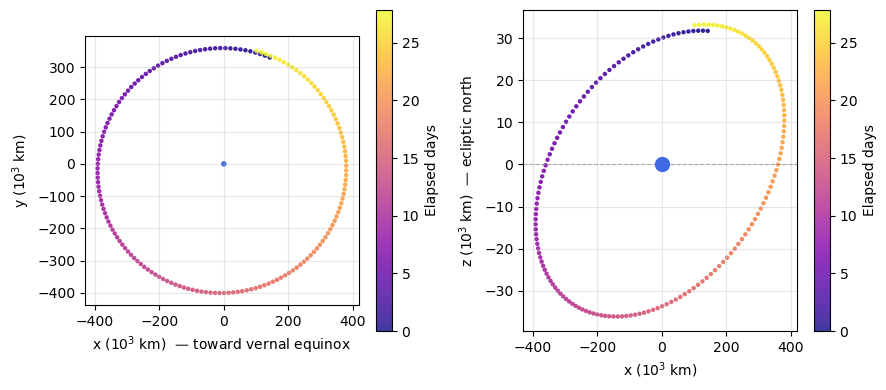

In [23]:
# plot_orbit.py
"""
Plots the Moon's geocentric orbit over 100 days
starting from 1 January 2026.

References:
    Meeus, J. (1998). Astronomical Algorithms, 2nd ed. Willmann-Bell.
    Chapront-Touze & Chapront (1983). A&A, 124, 50.
"""

def plot_moon_cycles():
    """
    Produce three plots:
      1. 3D orbit (x, y, z in km)
      2. 2D top-down: x-y plane (ecliptic plane view)
      3. 2D side-on:  x-z plane (shows orbital inclination)
    """
    x, y, z, t, lam, beta, delta = orbit_cartesian(
        2026, 1, 1, n_days=28, step_hours=4
    )

    earth_radius_km = 6371.0

    # ── Figure 1: 3D orbit ────────────────────────────────────────────────────
    fig1 = plt.figure(figsize=(10, 8))
    ax3d = fig1.add_subplot(111, projection='3d')

    sc = ax3d.scatter(x/1000, y/1000, z/1000,
                      c=t, cmap='plasma', s=4, alpha=0.8)
    ax3d.scatter([0], [0], [0],
                 color='royalblue', s=200, zorder=5, label='Earth')

    cb = fig1.colorbar(sc, ax=ax3d, pad=0.1, shrink=0.6)
    cb.set_label('Elapsed days', fontsize=10)

    ax3d.set_xlabel('x ($10^3$ km)', fontsize=10)
    ax3d.set_ylabel('y ($10^3$ km)', fontsize=10)
    ax3d.set_zlabel('z ($10^3$ km)', fontsize=10)
    # ax3d.set_title('Moon geocentric orbit — 100 days, 2026\n'
                #    '(geocentric ecliptic frame)', fontsize=11)
    ax3d.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('figures/orbit_3d.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Figure 2: 2D top-down and 2D side one ───────────────────────────

    fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(9, 4))

    # ── Left: top-down (x-y) ────────────────────────────────────────────
    sc2 = ax2.scatter(x/1000, y/1000, c=t, cmap='plasma', s=5, alpha=0.8)

    earth_circle = plt.Circle((0, 0), earth_radius_km/1000,
                            color='royalblue', label='Earth (to scale)')
    ax2.add_patch(earth_circle)

    cb2 = fig.colorbar(sc2, ax=ax2)
    cb2.set_label('Elapsed days', fontsize=10)

    ax2.set_aspect('equal')
    ax2.set_xlabel('x ($10^3$ km)  — toward vernal equinox', fontsize=10)
    ax2.set_ylabel('y ($10^3$ km)', fontsize=10)
    # ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    # ── Right: side-on (x-z) ────────────────────────────────────────────
    sc3 = ax3.scatter(x/1000, z/1000, c=t, cmap='plasma', s=5, alpha=0.8)

    ax3.axhline(0, color='gray', linewidth=0.8,
                linestyle='--', label='Ecliptic plane', alpha=0.6)

    ax3.scatter([0], [0], color='royalblue', s=100,
                zorder=5, label='Earth')

    cb3 = fig.colorbar(sc3, ax=ax3)
    cb3.set_label('Elapsed days', fontsize=10)

    ax3.set_xlabel('x ($10^3$ km)', fontsize=10)
    ax3.set_ylabel('z ($10^3$ km)  — ecliptic north', fontsize=10)
    # ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('figures/orbit_combined.png', dpi=150, bbox_inches='tight')
    plt.show()


if __name__ == "__main__":
    plot_moon_cycles()